In [1]:
"""
============================================
Title: CalCOFI Ocean Analysis
Author: Brittany Blessie
Date: 20 May 2026
Modified By: N/A
Description: This program conducts a comprehensive exploratory data 
analysis on the CalCOFI (California Cooperative Oceanic Fisheries 
Investigations) dataset to examine changes in water temperature and 
dissolved oxygen levels in California coastal waters from 1949 to 2021.
============================================
"""

'\n============================================\nTitle: CalCOFI Ocean Analysis\nAuthor: Brittany Blessie\nDate: 20 May 2026\nModified By: N/A\nDescription: This program conducts a comprehensive exploratory data \nanalysis on the CalCOFI (California Cooperative Oceanic Fisheries \nInvestigations) dataset to examine changes in water temperature and \ndissolved oxygen levels in California coastal waters from 1949 to 2021.\n============================================\n'

The CalCOFI dataset covers ocean monitoring off the California coast from 1949 to 2021, collected through a partnership between NOAA, Scripps Institution of Oceanography, and the California Department of Fish and Wildlife. This project looks at how water temperature and dissolved oxygen have changed over that period and whether the two are related. Salinity is included as a control variable since it affects how much oxygen water can hold.

## Section 1: Data Loading and Setup

In [2]:
# pandas/numpy: data manipulation and numerical operations
import pandas as pd
import numpy as np

# matplotlib/seaborn: data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# scipy.stats: hypothesis testing
from scipy import stats

# scikit-learn: regression, classification, clustering, ML
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (r2_score, mean_squared_error,
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, silhouette_score)

# suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# plot settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
df = pd.read_csv("194903-202105_Bottle.csv", encoding="latin-1")

In [4]:
df.head()

,Cst_Cnt,Btl_Cnt,Sta_ID,Depth_ID,Depthm,T_degC,Salnty,O2ml_L,STheta,O2Sat,...,R_DYNHT,R_Nuts,R_Oxy_µmol/Kg,DIC1,DIC2,TA1,TA2,pH1,pH2,DIC Quality Comment
0,1,1,054.0 056.0,19-4903CR-HY-060-0930-05400560-0000A-3,0,10.50,33.440,NaN,25.649,NaN,...,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2,054.0 056.0,19-4903CR-HY-060-0930-05400560-0008A-3,8,10.46,33.440,NaN,25.656,NaN,...,0.01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,3,054.0 056.0,19-4903CR-HY-060-0930-05400560-0010A-7,10,10.46,33.437,NaN,25.654,NaN,...,0.02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,4,054.0 056.0,19-4903CR-HY-060-0930-05400560-0019A-3,19,10.45,33.420,NaN,25.643,NaN,...,0.04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,5,054.0 056.0,19-4903CR-HY-060-0930-05400560-0020A-7,20,10.45,33.421,NaN,25.643,NaN,...,0.04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.shape

(895371, 62)

In [6]:
df.columns

Index(['Cst_Cnt', 'Btl_Cnt', 'Sta_ID', 'Depth_ID', 'Depthm', 'T_degC',
       'Salnty', 'O2ml_L', 'STheta', 'O2Sat', 'Oxy_µmol/Kg', 'BtlNum',
       'RecInd', 'T_prec', 'T_qual', 'S_prec', 'S_qual', 'P_qual', 'O_qual',
       'SThtaq', 'O2Satq', 'ChlorA', 'Chlqua', 'Phaeop', 'Phaqua', 'PO4uM',
       'PO4q', 'SiO3uM', 'SiO3qu', 'NO2uM', 'NO2q', 'NO3uM', 'NO3q', 'NH3uM',
       'NH3q', 'C14As1', 'C14A1p', 'C14A1q', 'C14As2', 'C14A2p', 'C14A2q',
       'DarkAs', 'DarkAp', 'DarkAq', 'MeanAs', 'MeanAp', 'MeanAq', 'IncTim',
       'LightP', 'R_Depth', 'R_TEMP', 'R_Sal', 'R_DYNHT', 'R_Nuts',
       'R_Oxy_µmol/Kg', 'DIC1', 'DIC2', 'TA1', 'TA2', 'pH1', 'pH2',
       'DIC Quality Comment'],
      dtype='object')

895,371 rows and 62 columns. Each row is one water sample at a specific depth. The columns I need are T_degC, O2ml_L, Salnty, and Depthm.

In [7]:
df[['Cst_Cnt', 'Sta_ID', 'Depth_ID']].head(10)


,Cst_Cnt,Sta_ID,Depth_ID
0,1,054.0 056.0,19-4903CR-HY-060-0930-05400560-0000A-3
1,1,054.0 056.0,19-4903CR-HY-060-0930-05400560-0008A-3
2,1,054.0 056.0,19-4903CR-HY-060-0930-05400560-0010A-7
3,1,054.0 056.0,19-4903CR-HY-060-0930-05400560-0019A-3
4,1,054.0 056.0,19-4903CR-HY-060-0930-05400560-0020A-7
5,1,054.0 056.0,19-4903CR-HY-060-0930-05400560-0030A-7
6,1,054.0 056.0,19-4903CR-HY-060-0930-05400560-0039A-3
7,1,054.0 056.0,19-4903CR-HY-060-0930-05400560-0050A-7
8,1,054.0 056.0,19-4903CR-HY-060-0930-05400560-0058A-3
9,1,054.0 056.0,19-4903CR-HY-060-0930-05400560-0075A-7


In [8]:
cast = pd.read_csv("194903-202105_Cast.csv", encoding="latin-1")

In [9]:
cast.head()

,Cst_Cnt,Cruise_ID,Cruise,Cruz_Sta,DbSta_ID,Cast_ID,Sta_ID,Quarter,Sta_Code,Distance,...,Wave_Prd,Wind_Dir,Wind_Spd,Barometer,Dry_T,Wet_T,Wea,Cloud_Typ,Cloud_Amt,Visibility
0,1,1949-03-01-C-31CR,194903,19490305400560,5400560,19-4903CR-HY-060-0930-05400560,054.0 056.0,1,NST,NaN,...,NaN,23.0,18.0,NaN,NaN,NaN,2.0,NaN,NaN,NaN
1,2,1949-03-01-C-31CR,194903,19490305200750,5200750,19-4903CR-HY-060-2112-05200750,052.0 075.0,1,NST,NaN,...,NaN,16.0,5.0,NaN,NaN,NaN,4.0,NaN,NaN,NaN
2,3,1949-03-01-C-31CR,194903,19490305100850,5100850,19-4903CR-HY-061-0354-05100850,051.0 085.0,1,NST,NaN,...,NaN,23.0,5.0,NaN,NaN,NaN,6.0,NaN,NaN,NaN
3,4,1949-03-01-C-31CR,194903,19490305000950,5000950,19-4903CR-HY-061-1042-05000950,050.0 095.0,1,NST,NaN,...,NaN,18.0,8.0,NaN,NaN,NaN,2.0,NaN,NaN,NaN
4,5,1949-03-01-C-31CR,194903,19490305001040,5001040,19-4903CR-HY-061-1706-05001040,050.0 104.0,1,NST,NaN,...,NaN,27.0,13.0,NaN,NaN,NaN,7.0,NaN,NaN,NaN


In [10]:
cast.columns

Index(['Cst_Cnt', 'Cruise_ID', 'Cruise', 'Cruz_Sta', 'DbSta_ID', 'Cast_ID',
       'Sta_ID', 'Quarter', 'Sta_Code', 'Distance', 'Date', 'Year', 'Month',
       'Julian_Date', 'Julian_Day', 'Time', 'Lat_Dec', 'Lat_Deg', 'Lat_Min',
       'Lat_Hem', 'Lon_Dec', 'Lon_Deg', 'Lon_Min', 'Lon_Hem', 'Rpt_Line',
       'St_Line', 'Ac_Line', 'Rpt_Sta', 'St_Station', 'Ac_Sta', 'Bottom_D',
       'Secchi', 'ForelU', 'Ship_Name', 'Ship_Code', 'Data_Type', 'Order_Occ',
       'Event_Num', 'Cruz_Leg', 'Orig_Sta_ID', 'Data_Or', 'Cruz_Num', 'IntChl',
       'IntC14', 'Inc_Str', 'Inc_End', 'PST_LAN', 'Civil_T', 'TimeZone',
       'Wave_Dir', 'Wave_Ht', 'Wave_Prd', 'Wind_Dir', 'Wind_Spd', 'Barometer',
       'Dry_T', 'Wet_T', 'Wea', 'Cloud_Typ', 'Cloud_Amt', 'Visibility'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 895371 entries, 0 to 895370
Data columns (total 62 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Cst_Cnt              895371 non-null  int64  
 1   Btl_Cnt              895371 non-null  int64  
 2   Sta_ID               895371 non-null  object 
 3   Depth_ID             895371 non-null  object 
 4   Depthm               895371 non-null  int64  
 5   T_degC               884402 non-null  float64
 6   Salnty               848015 non-null  float64
 7   O2ml_L               725630 non-null  float64
 8   STheta               842675 non-null  float64
 9   O2Sat                690746 non-null  float64
 10  Oxy_µmol/Kg          690698 non-null  float64
 11  BtlNum               138967 non-null  float64
 12  RecInd               895371 non-null  int64  
 13  T_prec               884408 non-null  float64
 14  T_qual               24016 non-null   float64
 15  S_prec           

### Variable Descriptions

This project uses four variables from the CalCOFI bottle dataset:

T_degC: Water temperature in degrees Celsius, measured at the depth where the sample was collected. This is one of the two primary variables in the analysis.

O2ml_L: Dissolved oxygen in milliliters per liter. This is the second primary variable. Oxygen levels in the ocean depend on depth, wave mixing, biological activity, and temperature.

Salnty: Salinity in practical salinity units (PSU). Included as a control variable because salinity affects how much dissolved oxygen water can physically hold. Higher salinity reduces oxygen solubility.

Depthm: Depth in meters where the water sample was taken. Ranges from 0 (surface) to over 5,000 meters. Depth acts as a confounding variable throughout this analysis because it drives both temperature and oxygen levels.

Date, Year, and Month come from the Cast dataset and are used for time trend analysis. Lat_Dec and Lon_Dec provide geographic coordinates for each sampling station.

## Section 2: Narrowing Columns

We do not need all of the data for this specific test

In [12]:
df_bottle = df[['Cst_Cnt', 'Depthm', 'T_degC', 'Salnty', 'O2ml_L']]
df_cast = cast[['Cst_Cnt', 'Date', 'Year', 'Month', 'Lat_Dec', 'Lon_Dec']]

In [13]:
print(df_bottle.shape)
print(df_cast.shape)

(895371, 5)
(35644, 6)


## Section 3: Merging DataFrames

I am merging the DataFrames because we need date and location for each bottle of water collected and need to make sure that it is aligned correctly. The two DataFrames are linked by Cst_Cnt, which is the common variable in both datasets.

In [14]:
df_merged = df_bottle.merge(df_cast, on='Cst_Cnt', how='inner')

In [15]:
df_merged.shape

(895371, 10)

In [16]:
df_merged.head()

,Cst_Cnt,Depthm,T_degC,Salnty,O2ml_L,Date,Year,Month,Lat_Dec,Lon_Dec
0,1,0,10.50,33.440,NaN,03/01/1949,1949,3,38.833333,-124.083333
1,1,8,10.46,33.440,NaN,03/01/1949,1949,3,38.833333,-124.083333
2,1,10,10.46,33.437,NaN,03/01/1949,1949,3,38.833333,-124.083333
3,1,19,10.45,33.420,NaN,03/01/1949,1949,3,38.833333,-124.083333
4,1,20,10.45,33.421,NaN,03/01/1949,1949,3,38.833333,-124.083333


In [17]:
df_merged.isnull().sum()

Cst_Cnt         0
Depthm          0
T_degC      10969
Salnty      47356
O2ml_L     169741
Date            0
Year            0
Month           0
Lat_Dec         0
Lon_Dec         0
dtype: int64

O2ml_L has 169,741 missing values, T_degC has 10,969, and Salnty has 47,356. The merge itself worked cleanly since Date, Year, Month, Lat_Dec, and Lon_Dec all came through with no nulls.

## Section 4: Data Cleaning

In [18]:
df_clean = df_merged.dropna(subset=['T_degC', 'O2ml_L'])

In [19]:
df_clean.shape

(720712, 10)

In [20]:
# generate summary statistics for the four key variables
df_clean[['T_degC', 'O2ml_L', 'Salnty', 'Depthm']].describe()

,T_degC,O2ml_L,Salnty,Depthm
count,720712.000000,720712.000000,690914.000000,720712.000000
mean,10.877251,3.390777,33.819091,222.692467
std,4.220560,2.084741,0.537729,312.580565
min,1.440000,-200.222000,24.189670,0.000000
25%,7.770000,1.360000,33.478000,50.000000
50%,10.120000,3.430000,33.844300,125.000000
75%,13.980000,5.500000,34.180000,300.000000
max,31.140000,11.130000,37.034000,5351.000000


T_degC ranges from 1.44 to 31.14°C with a mean of 10.88. O2ml_L runs from 0 to 11.13 ml/L with a mean of 3.39 and a standard deviation of 2.07, which is large relative to the mean and reflects how much oxygen varies by depth. Salinity stays tight between 24.19 and 37.03 with a mean of 33.82, consistent with open ocean water. Depth goes from 0 down to 5,351 meters covering surface samples all the way to deep water casts.

I needed to drop any rows that are missing either temperature or oxygen levels or both due to the fact that those are my main variables and I cannot be missing either of them

In [21]:
df_clean.isnull().sum()

Cst_Cnt        0
Depthm         0
T_degC         0
Salnty     29798
O2ml_L         0
Date           0
Year           0
Month          0
Lat_Dec        0
Lon_Dec        0
dtype: int64

In [22]:
salinity_median = df_clean['Salnty'].median()
df_clean.loc[:, 'Salnty'] = df_clean['Salnty'].fillna(salinity_median)

In [23]:
df_clean.isnull().sum()

Cst_Cnt    0
Depthm     0
T_degC     0
Salnty     0
O2ml_L     0
Date       0
Year       0
Month      0
Lat_Dec    0
Lon_Dec    0
dtype: int64

Salinity still had 29,798 missing values after dropping the temperature and oxygen nulls. Since salinity is a control variable and not one of my main variables, I filled the missing values with the median instead of dropping those rows. I used the median rather than the mean because California coastal waters get freshwater input from rivers and runoff, which can pull salinity low and skew a mean.

In [24]:
df_clean.describe()

,Cst_Cnt,Depthm,T_degC,Salnty,O2ml_L,Year,Month,Lat_Dec,Lon_Dec
count,720712.000000,720712.000000,720712.000000,720712.000000,720712.000000,720712.000000,720712.000000,720712.000000,720712.000000
mean,18545.537641,222.692467,10.877251,33.820133,3.390777,1977.643937,5.797044,31.825809,-120.268962
std,11000.379474,312.580565,4.220560,0.526519,2.084741,22.598188,3.318828,3.556756,3.956399
min,71.000000,0.000000,1.440000,24.189670,-200.222000,1949.000000,1.000000,18.416666,-157.983333
25%,9195.000000,50.000000,7.770000,33.490000,1.360000,1957.000000,3.000000,30.180000,-122.530000
50%,19167.000000,125.000000,10.120000,33.844300,3.430000,1974.000000,6.000000,32.375000,-120.350000
75%,28726.000000,300.000000,13.980000,34.166000,5.500000,1998.000000,8.000000,33.723333,-117.925000
max,35644.000000,5351.000000,31.140000,37.034000,11.130000,2021.000000,12.000000,47.916666,-105.966666


In [25]:
df_clean = df_clean[df_clean['O2ml_L'] >= 0]

In [26]:
df_clean.describe()

,Cst_Cnt,Depthm,T_degC,Salnty,O2ml_L,Year,Month,Lat_Dec,Lon_Dec
count,720707.000000,720707.000000,720707.000000,720707.000000,720707.000000,720707.000000,720707.000000,720707.000000,720707.000000
mean,18545.455322,222.690904,10.877268,33.820131,3.391078,1977.643760,5.797040,31.825793,-120.268966
std,11000.371080,312.580528,4.220556,0.526520,2.070890,22.598154,3.318834,3.556763,3.956412
min,71.000000,0.000000,1.440000,24.189670,0.000000,1949.000000,1.000000,18.416666,-157.983333
25%,9195.000000,50.000000,7.770000,33.490000,1.360000,1957.000000,3.000000,30.180000,-122.530000
50%,19167.000000,125.000000,10.120000,33.844300,3.430000,1974.000000,6.000000,32.375000,-120.350000
75%,28726.000000,300.000000,13.980000,34.166000,5.500000,1998.000000,8.000000,33.723333,-117.925000
max,35644.000000,5351.000000,31.140000,37.034000,11.130000,2021.000000,12.000000,47.916666,-105.966666


While reviewing the summary statistics, I noticed that the minimum dissolved oxygen value was negative, which is physically impossible in nature. Any rows containing oxygen levels below zero were removed to preserve the integrity of the dataset. Temperature values range from 1.4°C to 31.14°C. While these values appear extreme, both are physically plausible for California coastal waters. The minimum could reflect cold water brought south by the California Current during strong upwelling events, while the maximum could occur in shallow coastal waters during a hot summer or a strong El Niño year. No temperature values were removed.

## Section 5: Univariate Analysis

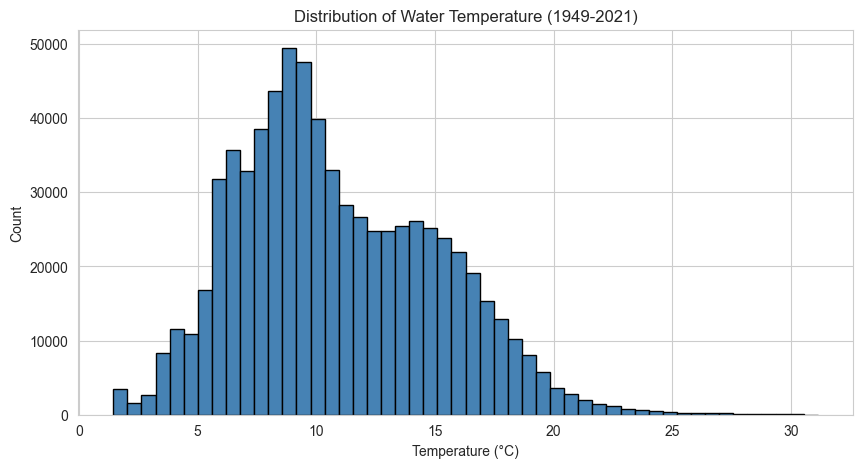

In [27]:
plt.figure(figsize=(10, 5))
plt.hist(df_clean['T_degC'], bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of Water Temperature (1949-2021)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Count')
plt.show()

The distribution of water temperature is positively skewed, with most observations falling between 5 and 15°C. The skew is driven by a small number of unusually warm temperature readings that pull the mean (10.88°C) slightly higher than the median (10.12°C).

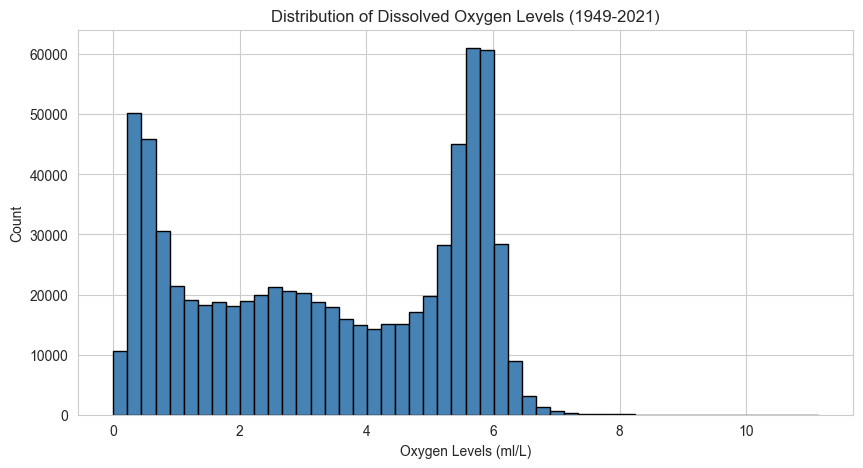

In [28]:
plt.figure(figsize=(10, 5))
plt.hist(df_clean['O2ml_L'], bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of Dissolved Oxygen Levels (1949-2021)')
plt.xlabel('Oxygen Levels (ml/L)')
plt.ylabel('Count')
plt.show()

The distribution of dissolved oxygen levels appears bimodal, meaning there are two distinct clusters of values. The first cluster near 0.5 ml/L likely represents deep water samples where there is little sunlight and no wave mixing to introduce oxygen. The second larger cluster around 6 ml/L likely represents shallower surface waters where wave action and phytoplankton photosynthesis produce higher oxygen levels.

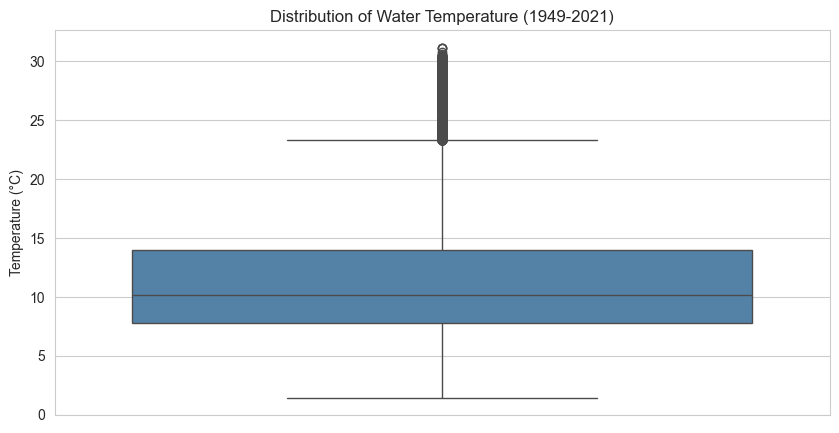

In [29]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_clean, y='T_degC', color='steelblue')
plt.title('Distribution of Water Temperature (1949-2021)')
plt.ylabel('Temperature (°C)')
plt.show()

The box plot confirms that the middle 50% of water temperature observations fall between 7.77°C and 13.98°C, with a median of 10.12°C. The whiskers extend to the minimum and maximum reasonable values, while the single dot near 30°C represents an outlier, consistent with the right skew observed in the histogram.

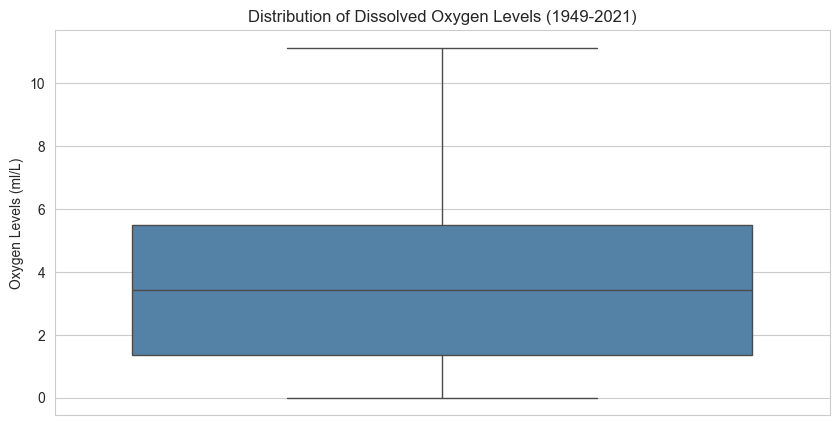

In [30]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_clean, y='O2ml_L', color='steelblue')
plt.title('Distribution of Dissolved Oxygen Levels (1949-2021)')
plt.ylabel('Oxygen Levels (ml/L)')
plt.show()

The dissolved oxygen box plot shows the middle 50% of values falling between approximately 1.7 and 6 ml/L, with a median of 3.43 ml/L. Unlike the temperature box plot, there are no outlier dots beyond the whiskers. However the box is visibly wider than the temperature box plot, suggesting that dissolved oxygen levels are less consistent and more variable across the dataset.

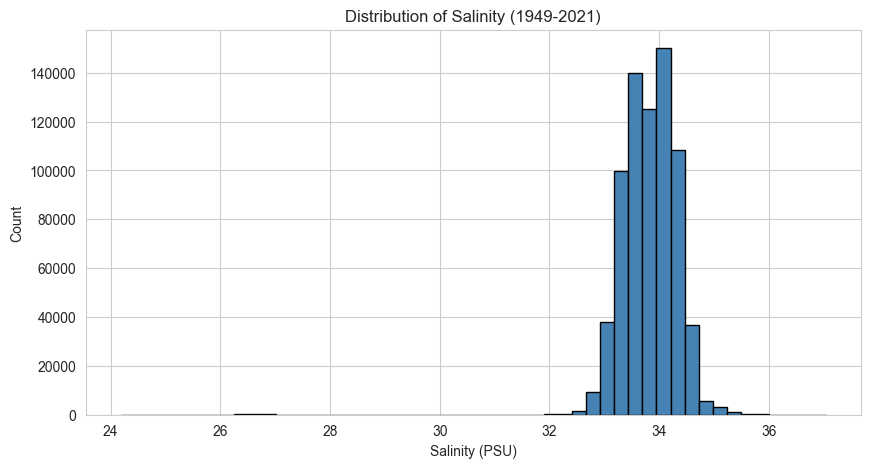

In [31]:
# salinity distribution to complete univariate analysis of all three key variables
plt.figure(figsize=(10, 5))
plt.hist(df_clean['Salnty'], bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of Salinity (1949-2021)')
plt.xlabel('Salinity (PSU)')
plt.ylabel('Count')
plt.show()

Most salinity values cluster tightly around 34 PSU, which is normal for open ocean water off the California coast. The strong negative skew (-4.231) shows up as a long left tail stretching down to about 24 PSU. Those low readings are probably from samples collected near river mouths or after heavy rainfall pushed freshwater into the sampling area.

## Section 6: Bivariate Analysis

In [32]:
df_clean[['T_degC', 'O2ml_L', 'Salnty']].corr()

,T_degC,O2ml_L,Salnty
T_degC,1.000000,0.799109,-0.425482
O2ml_L,0.799109,1.000000,-0.687493
Salnty,-0.425482,-0.687493,1.000000


The correlation matrix shows a strong positive correlation of 0.799 between water temperature and dissolved oxygen. That sounds backwards since warmer water holds less oxygen, but depth is the confounding variable here. Shallow water is warmer and oxygen-rich; deep water is colder and oxygen-depleted, so both variables move in the same direction. Salinity shows a negative correlation with temperature (-0.425) and oxygen (-0.687), driven by the same depth dynamic.

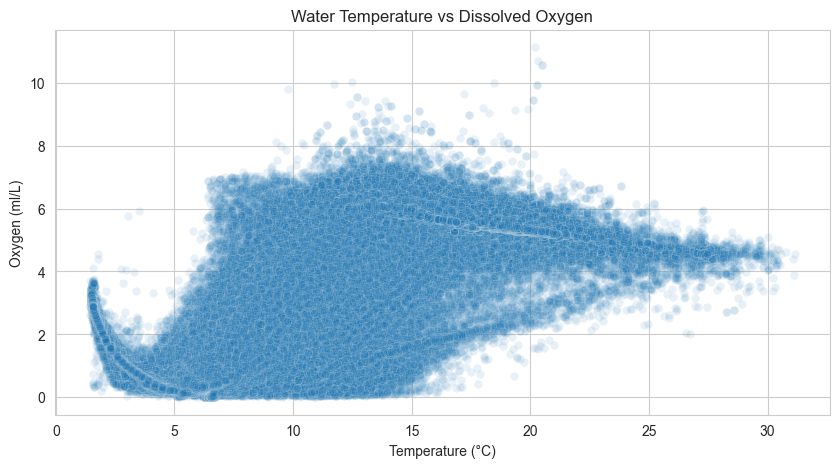

In [33]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_clean, x='T_degC', y='O2ml_L', alpha=0.1)
plt.title('Water Temperature vs Dissolved Oxygen')
plt.xlabel('Temperature (°C)')
plt.ylabel('Oxygen (ml/L)')
plt.show()

The scatter plot reveals a non-linear relationship between water temperature and dissolved oxygen, producing a distinctive curved shape. The left side of the plot, where temperatures are coldest, shows the widest spread of oxygen values, likely representing deep water samples where oxygen can vary dramatically. As temperature increases toward the right, oxygen values narrow and flatten out, consistent with shallower coastal waters during warmer seasons. This non-linear pattern confirms that the relationship between temperature and oxygen is more complex than a simple straight line.

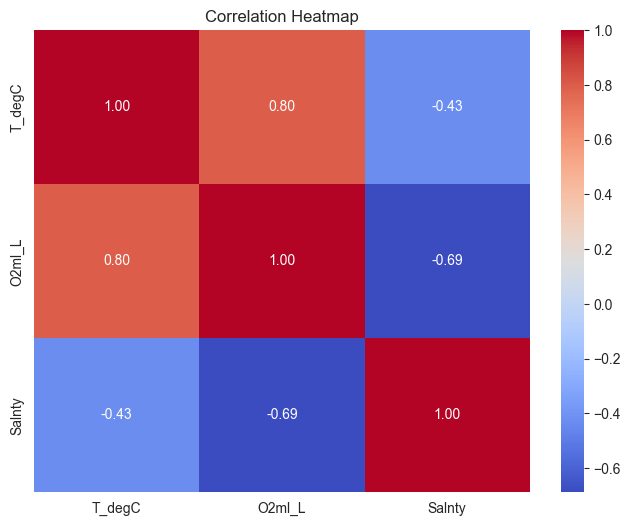

In [34]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_clean[['T_degC', 'O2ml_L', 'Salnty']].corr(), 
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

The heatmap confirms that the strongest positive correlation exists between water temperature and dissolved oxygen at 0.80, meaning these two variables tend to move in the same direction. The strongest negative correlation is between dissolved oxygen and salinity at -0.69, meaning as salinity increases, oxygen decreases. This pattern is consistent with the depth dynamic discussed earlier: shallow water tends to be warmer, higher in oxygen, and lower in salinity, while deep water tends to be colder, lower in oxygen, and higher in salinity. Depth acts as the underlying driver connecting all three variables.

## Section 7: Hypothesis Testing

In [35]:
corr, pvalue = stats.pearsonr(df_clean['T_degC'], df_clean['O2ml_L'])
print(f'Correlation: {corr:.4f}')
print(f'P-value: {pvalue:.4f}')

Correlation: 0.7991
P-value: 0.0000


**H0**: There is no statistically significant correlation between water temperature and dissolved oxygen in California coastal waters. Any observed relationship is due to random chance.

**H1**: There is a statistically significant correlation between water temperature and dissolved oxygen in California coastal waters.

Running the Pearson correlation test produced a correlation coefficient of 0.7991 and a p-value of essentially 0.0000, which is far below the standard significance threshold of 0.05. We therefore reject the null hypothesis and conclude that the relationship between water temperature and dissolved oxygen is statistically significant and extremely unlikely to be due to random chance.

## Section 8: Regression Analysis

In [36]:
X = df_clean[['T_degC']]
y = df_clean['O2ml_L']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)

(576565, 1)
(144142, 1)


In [37]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [38]:
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(f'R-squared: {r2:.4f}')
print(f'MSE: {mse:.4f}')

R-squared: 0.6385
MSE: 1.5539


Linear regression attempts to predict dissolved oxygen levels based on water temperature using a straight line. The model produced an R² of 0.6385, meaning that approximately 64% of the variation in dissolved oxygen levels can be explained by temperature alone. However, the remaining 36% is influenced by other factors such as depth, season, and location. The moderate R² is expected given that the scatter plot revealed a non-linear shark fin shaped relationship between temperature and oxygen, which a straight line cannot fully capture. A polynomial regression model may provide a better fit.

In [39]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_poly_train, y_train)

y_poly_pred = poly_model.predict(X_poly_test)
r2_poly = r2_score(y_test, y_poly_pred)
mse_poly = mean_squared_error(y_test, y_poly_pred)

print(f'Polynomial R-squared: {r2_poly:.4f}')
print(f'Polynomial MSE: {mse_poly:.4f}')

Polynomial R-squared: 0.6968
Polynomial MSE: 1.3031


The polynomial regression model produced an R² of 0.6968, a modest improvement of approximately 6% over the linear model. While adding a curved line allows the model to better follow the non-linear shark fin shape in the data, the improvement is limited because temperature alone cannot fully explain dissolved oxygen levels. Depth acts as a confounding variable that drives both temperature and oxygen in the same direction, meaning a model that only uses temperature as a predictor will always have limited explanatory power. Including depth as an additional predictor variable would likely improve the model significantly.

## Section 9: Classification

In [40]:
df_clean['O2_class'] = (df_clean['O2ml_L'] >= 3.43).astype(int)

df_clean['O2_class'].value_counts()

O2_class
1    360776
0    359931
Name: count, dtype: int64

In [41]:
# logistic regression to classify high vs low oxygen
# using temperature and salinity as predictors
X_clf = df_clean[['T_degC', 'Salnty']]
y_clf = df_clean['O2_class']

X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_clf_train, y_clf_train)

y_log_pred = log_model.predict(X_clf_test)
print(classification_report(y_clf_test, y_log_pred))
print(f"Logistic Regression Accuracy: {accuracy_score(y_clf_test, y_log_pred):.4f}")

              precision    recall  f1-score   support

           0       0.94      0.95      0.95     71989
           1       0.95      0.94      0.95     72153

    accuracy                           0.95    144142
   macro avg       0.95      0.95      0.95    144142
weighted avg       0.95      0.95      0.95    144142

Logistic Regression Accuracy: 0.9483


Logistic Regression classified high vs low oxygen with 94.8% accuracy. Precision and recall are both at 0.94-0.95 for each class, meaning the model is balanced and not favoring one group over the other. This is a strong result for a simple linear classifier using only two predictors.

## Section 10: Machine Learning Classification

The Random Forest Classifier is used here as a more advanced ML approach to the same classification problem. Random Forest builds multiple decision trees and combines their predictions, which allows it to capture non-linear relationships that logistic regression cannot.

In [42]:
X_clf = df_clean[['T_degC', 'Salnty']]
y_clf = df_clean['O2_class']

X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_clf_train, y_clf_train)

RandomForestClassifier(random_state=42)

In [43]:
y_clf_pred = rf_model.predict(X_clf_test)
print(classification_report(y_clf_test, y_clf_pred))
print(f'Accuracy: {accuracy_score(y_clf_test, y_clf_pred):.4f}')

              precision    recall  f1-score   support

           0       0.95      0.95      0.95     71989
           1       0.95      0.95      0.95     72153

    accuracy                           0.95    144142
   macro avg       0.95      0.95      0.95    144142
weighted avg       0.95      0.95      0.95    144142

Accuracy: 0.9494


The Random Forest Classifier achieved 95.0% accuracy, a slight improvement over Logistic Regression's 94.8%. The improvement is small because the relationship between temperature, salinity, and oxygen class is already mostly linear, so the added complexity of Random Forest doesn't buy much. In cases where the relationship is more non-linear, the gap would likely be larger.

## Section 11: Clustering

In [44]:
scaler = StandardScaler()
X_cluster = df_clean[['T_degC', 'O2ml_L', 'Salnty']]
X_scaled = scaler.fit_transform(X_cluster)

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)

df_clean['Cluster'] = kmeans.labels_
print(df_clean['Cluster'].value_counts())

  File "C:\Users\brittany.blessie\AppData\Local\miniconda3\envs\book_env\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "C:\Users\brittany.blessie\AppData\Local\miniconda3\envs\book_env\lib\subprocess.py", line 493, in run
    with Popen(*popenargs, **kwargs) as process:
  File "C:\Users\brittany.blessie\AppData\Local\miniconda3\envs\book_env\lib\subprocess.py", line 858, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\brittany.blessie\AppData\Local\miniconda3\envs\book_env\lib\subprocess.py", line 1327, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


Cluster
1    278815
2    246137
0    195755
Name: count, dtype: int64


In [45]:
df_clean.groupby('Cluster')[['T_degC', 'O2ml_L', 'Salnty']].mean()

,T_degC,O2ml_L,Salnty
Cluster,,,
0,9.774937,3.308345,33.813496
1,15.103130,5.589416,33.432075
2,6.967059,0.966681,34.264984


In [46]:
# silhouette score on a random sample of 10,000 points
# full dataset is too large to compute efficiently
from sklearn.utils import resample
X_sample, labels_sample = resample(X_scaled, kmeans.labels_, 
    n_samples=10000, random_state=42)
sil_score = silhouette_score(X_sample, labels_sample)
print(f"Silhouette Score (sampled): {sil_score:.4f}")

Silhouette Score (sampled): 0.4353


The silhouette score of 0.44 indicates moderately well-defined clusters. A score of 1.0 would mean perfectly separated groups, while 0 would mean overlapping. The moderate score makes sense here because ocean water masses blend into each other gradually rather than having hard boundaries.

Cluster 1 is warm, high oxygen, lower salinity surface water. Cluster 0 is the middle layer with moderate values. Cluster 2 is cold, near-zero oxygen, higher salinity deep water. The algorithm found these groupings on its own and they match known oceanographic water mass types pretty closely.

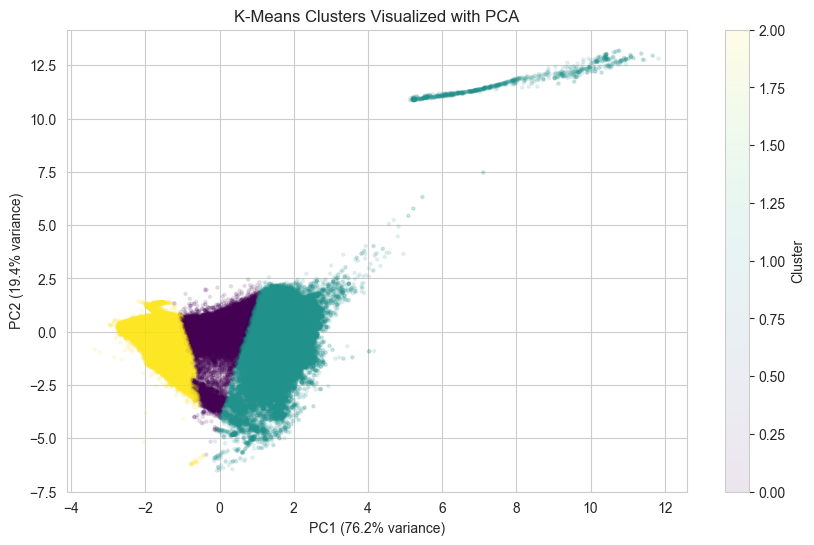

In [47]:
# PCA reduces the 3 variables to 2 dimensions for visualization
# this lets us see how the clusters are separated in 2D space
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
    c=df_clean['Cluster'], cmap='viridis', alpha=0.1, s=5)
plt.colorbar(scatter, label='Cluster')
plt.title('K-Means Clusters Visualized with PCA')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.show()

The PCA plot reduces the three variables (temperature, oxygen, salinity) down to two dimensions. PC1 captures 76.2% of the variance and PC2 captures 19.4%, so together they represent 95.6% of the total variation in the data. The three clusters are visibly separated: the yellow cluster (deep cold water) sits in the lower left, the purple cluster (mid-depth transitional water) fills the center, and the green cluster (warm surface water) stretches to the upper right. The separation confirms that the k-means algorithm found real structure in the data rather than arbitrary groupings.

## Section 12: Time Trend Analysis

In [48]:
yearly_avg = df_clean.groupby('Year')[['T_degC', 'O2ml_L']].mean()

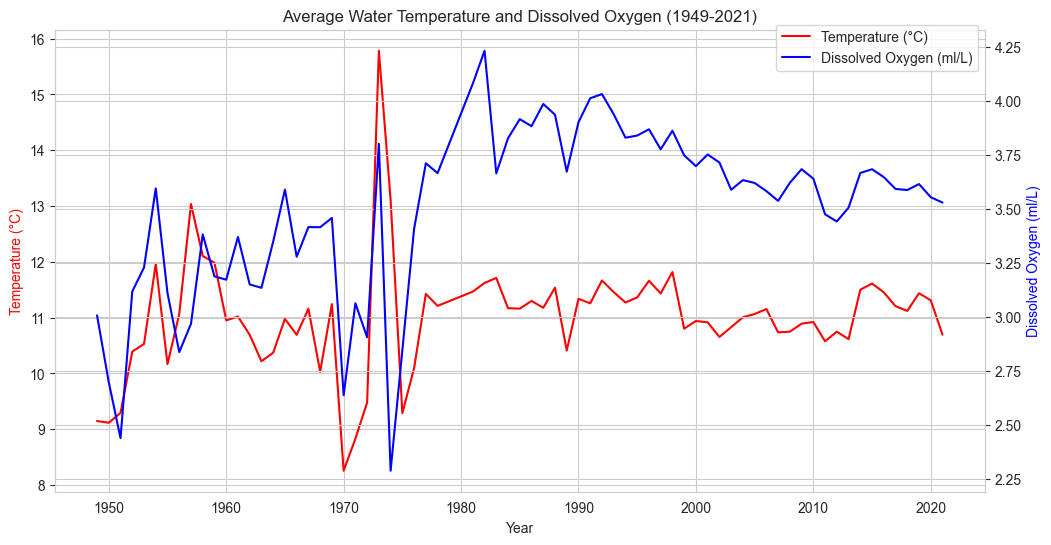

In [49]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(yearly_avg.index, yearly_avg['T_degC'], color='red', label='Temperature (°C)')
ax1.set_xlabel('Year')
ax1.set_ylabel('Temperature (°C)', color='red')

ax2 = ax1.twinx()
ax2.plot(yearly_avg.index, yearly_avg['O2ml_L'], color='blue', label='Dissolved Oxygen (ml/L)')
ax2.set_ylabel('Dissolved Oxygen (ml/L)', color='blue')

plt.title('Average Water Temperature and Dissolved Oxygen (1949-2021)')
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.9))
plt.show()

Before 1970 there's a lot of noise, which makes sense given how early the program was and how much sampling methods varied in those decades. Around 1970 there's a sharp temperature drop followed by a spike, consistent with a La Niña to El Niño transition. From the 1980s onward the two variables track each other pretty closely. Both show a declining trend through 2021, which lines up with the La Niña conditions documented through 2025-2026. NOAA is forecasting a strong El Niño emerging in mid to late 2026, so this dataset may be catching the tail end of that cycle.